# CNN Chest X-Ray Classifier — Starter Notebook

Fill in every `# TODO` below to complete the exercise. Each section explains
the **concept** first, then gives you a scaffolded cell with hints — the
structure is provided, the logic is yours to write.

**Dataset:** [Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia) (Kaggle, ~1.2GB, binary classification NORMAL vs PNEUMONIA).

**Learning objectives** — by the end you should be able to:
- Build an image preprocessing pipeline that handles inconsistent inputs (size, color mode)
- Diagnose and correct for class imbalance
- Build and train a CNN from scratch
- Evaluate a classifier properly when imbalance is present (accuracy alone will lie to you here)


## Step 0 — Setup

Nothing to fill in here — just run it.

In [1]:
import os, math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)
rng = np.random.default_rng(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Step 1 — Get the Data

Use the real Kaggle dataset for your actual submission

In [2]:
DATA_ROOT = "chest_xray"

print("Dataset found:", os.path.exists(DATA_ROOT))

Dataset found: True


## Task 1 — Inspect Before You Touch Anything

**Concept:** every downstream decision (splitting, preprocessing, weighting,
evaluating) depends on facts about the raw data. Before writing a single line
of model code, confirm two things: how imbalanced the classes are, and how
inconsistent the raw images are (size, color mode). Skipping this step is how
people accidentally train on a 3:1 imbalanced set while assuming it's
balanced.


In [3]:
# TODO 1a: Count how many images are in each class, for both 'train' and 'test'.
for split in ["train", "test"]:
    print(f"\n{split.upper()}")

    for cls in ["NORMAL", "PNEUMONIA"]:
        path = os.path.join(DATA_ROOT, split, cls)
        count = len(os.listdir(path))
        print(f"{cls}: {count}")


TRAIN
NORMAL: 1341
PNEUMONIA: 3875

TEST
NORMAL: 234
PNEUMONIA: 390


In [4]:
# TODO 1b: For 5 sample images per class in `train/`, print their size and color mode.
for cls in ["NORMAL", "PNEUMONIA"]:
    path = os.path.join(DATA_ROOT, "train", cls)

    print(f"\n{cls}")

    for file in os.listdir(path)[:5]:
        img = Image.open(os.path.join(path, file))
        print(img.size, img.mode)


NORMAL
(2090, 1858) L
(1422, 1152) L
(1810, 1434) L
(1618, 1279) L
(1600, 1125) L

PNEUMONIA
(1152, 760) L
(1072, 768) L
(1244, 863) L
(1242, 940) L
(1488, 1280) L


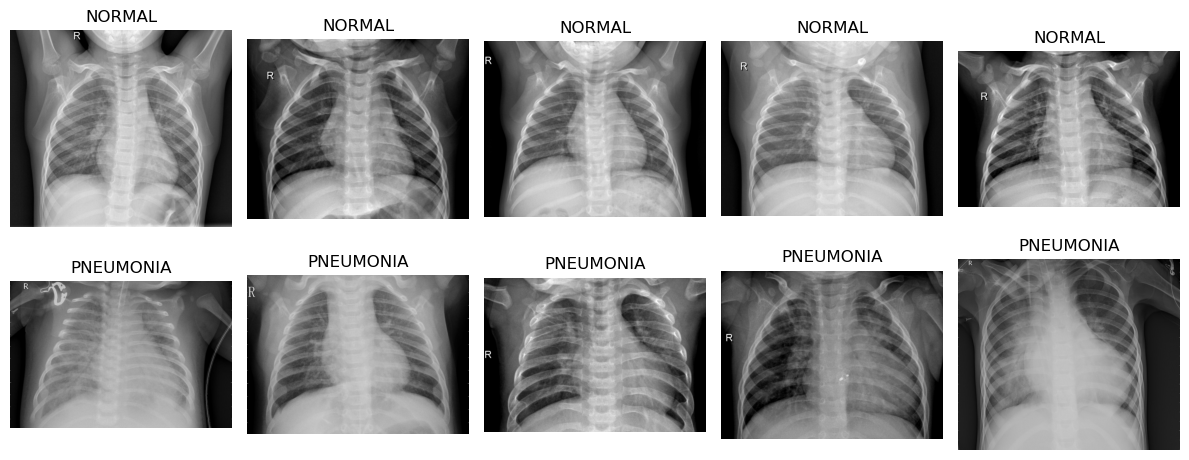

In [5]:
# TODO 1c: Display a 2x5 grid of sample images (5 NORMAL, 5 PNEUMONIA) so you can eyeball them.
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for row, cls in enumerate(["NORMAL", "PNEUMONIA"]):
    path = os.path.join(DATA_ROOT, "train", cls)
    files = os.listdir(path)[:5]

    for col, file in enumerate(files):
        img = Image.open(os.path.join(path, file))
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(cls)
        axes[row, col].axis("off")

plt.tight_layout()

In [6]:
# TODO 1d: Compute the class imbalance ratio in the TRAIN set (PNEUMONIA count / NORMAL count).
n_normal = len(os.listdir(os.path.join(DATA_ROOT, "train", "NORMAL")))
n_pneumonia = len(os.listdir(os.path.join(DATA_ROOT, "train", "PNEUMONIA")))

imbalance_ratio = n_pneumonia / n_normal

print("NORMAL:", n_normal)
print("PNEUMONIA:", n_pneumonia)
print(f"Imbalance ratio: {imbalance_ratio:.2f}x")

NORMAL: 1341
PNEUMONIA: 3875
Imbalance ratio: 2.89x


**Checkpoint — before moving on, answer for yourself:** roughly what's the
imbalance ratio you found, and are image sizes/modes actually consistent or
not? Both answers directly shape what you build next.

* PNEUMONIA is roughly 2.89x times more common than NORMAL.
* Sizes are inconsistent, and modes are L (grayscale).

## Task 2 — Build a Proper Train/Validation Split

**Concept — why we ignore the provided `val/` folder:** it only has 16
images. Any accuracy/loss number computed on 16 samples has huge variance —
getting one extra image right or wrong swings the metric by more than 6
percentage points. That's not reliable enough to base decisions on (like when
to stop training).

**Concept — stratified split:** a plain random split can accidentally skew
the class ratio between train and validation, especially with imbalance
already present. A *stratified* split preserves the same class ratio in both
subsets, so validation performance is actually representative.

**Concept — why `test/` stays untouched:** validation is used *during*
development (tuning, early stopping). The test set is only evaluated once, at
the very end, for an honest read on real-world performance. Don't peek at it
before then.


In [7]:
# TODO 2a: Build two parallel lists: all_paths (full file path to every train image)
all_paths = []
all_labels = []

for cls, label in [("NORMAL", 0), ("PNEUMONIA", 1)]:
    folder = os.path.join(DATA_ROOT, "train", cls)

    for file in os.listdir(folder):
        all_paths.append(os.path.join(folder, file))
        all_labels.append(label)

print("Total images:", len(all_paths))

Total images: 5216


In [8]:
# TODO 2b: Use sklearn's train_test_split to create an 85/15 train/val split,
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths,
    all_labels,
    test_size=0.15,
    stratify=all_labels,
    random_state=42
)

print(f"Train: {len(train_paths)}")
print(f"Validation: {len(val_paths)}")

print(f"Train pneumonia ratio: {sum(train_labels)/len(train_labels):.3f}")
print(f"Val pneumonia ratio: {sum(val_labels)/len(val_labels):.3f}")

Train: 4433
Validation: 783
Train pneumonia ratio: 0.743
Val pneumonia ratio: 0.743


## Task 3 — Preprocessing Pipeline

Five sub-steps, in this specific order (order matters — think about why
before moving to Task 4):

1. **Resize** every image to a fixed size — networks need constant-shape tensors to batch.
2. **Convert to one color mode** (grayscale) — X-rays carry no real color signal; dropping RGB triples cuts compute ~3x.
3. **Normalize to [0, 1]** — keeps gradients well-behaved during training.
4. **Augment training data only** — regularization via synthetic variety; augmenting val/test would corrupt your evaluation of real-world performance.
5. **Compute class weights from the *original* counts** (Task 1's numbers), *before* augmentation — augmentation doesn't change real-world class prevalence, so weighting must reflect the true distribution.


In [9]:
IMG_SIZE = 96
BATCH_SIZE = 16

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=1, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0

    return img, label


def augment_image(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.1)
    img = tf.clip_by_value(img, 0, 1)

    return img, label


def build_dataset(paths, labels, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        ds = ds.shuffle(1000)
        ds = ds.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)

    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


train_ds = build_dataset(train_paths, train_labels, augment=True)
val_ds = build_dataset(val_paths, val_labels)

for imgs, lbls in train_ds.take(1):
    print("Batch shape:", imgs.shape)
    print("Value range:", tf.reduce_min(imgs).numpy(), "-", tf.reduce_max(imgs).numpy())

Batch shape: (16, 96, 96, 1)
Value range: 0.0 - 1.0


what this does 
Image -> Grayscale (1 channel)-> Resize to 96 × 96 -> Normalize to 0–1 -> Training only: Shuffle + Flip + Brightness augmentation-> Batch into groups of 16

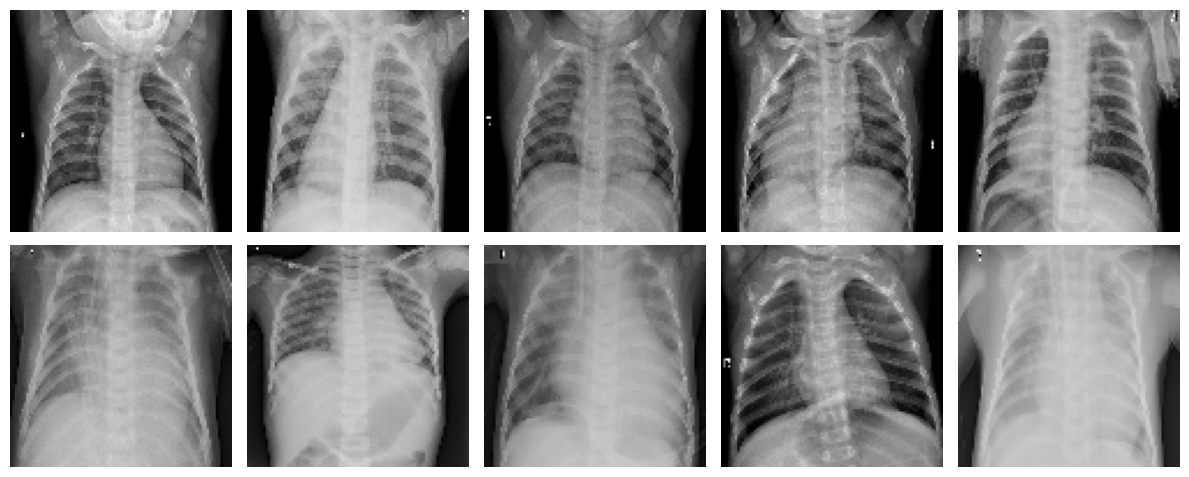

In [11]:
# TODO 3d: Visualize a few augmented training images next to their un-augmented val counterparts.
train_imgs, _ = next(iter(train_ds))
val_imgs, _ = next(iter(val_ds))

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i in range(5):
    axes[0, i].imshow(train_imgs[i], cmap="gray")
    axes[0, i].axis("off")

    axes[1, i].imshow(val_imgs[i], cmap="gray")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Train", fontsize=12)
axes[1, 0].set_ylabel("Val", fontsize=12)

plt.tight_layout()
plt.show()

In [12]:
# TODO 3e: Compute class weights from the ORIGINAL train label counts (from Task 1/2),
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=np.array(train_labels)
)

class_weight_dict = {
    0: weights[0],
    1: weights[1]
}

print(class_weight_dict)

{0: np.float64(1.9442982456140352), 1: np.float64(0.6730944427573641)}


## Task 4 — Build the CNN

**Concept recap for each layer type:**
- **Conv2D** — learns local spatial features (edges → textures → shapes across blocks).
- **BatchNorm** — normalizes activations for stabler, faster training.
- **ReLU** — the non-linearity; without it, stacked conv layers collapse into one linear function.
- **MaxPool** — downsamples feature maps, cuts compute, adds translation tolerance.
- **Dropout** — randomly zeroes neurons before the dense layers to fight overfitting on this small dataset.
- **Sigmoid output** — single neuron producing a (0,1) probability for binary classification.

Build from scratch (no pretrained weights) — this makes the benefit of
transfer learning in the Bonus section measurable rather than assumed.


In [13]:
# TODO 4: Build a Sequential CNN with:
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),

    layers.Conv2D(32, 3, padding="same"),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding="same"),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding="same"),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dropout(0.5),

    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,453,121 (9.36 MB)

 Trainable params: 2,452,673 (9.36 MB)

 Non-trainable params: 448 (1.75 KB)

## Task 5 — Train With the Right Settings

- Pass `class_weight` (from Task 3e) into `model.fit()` so NORMAL mistakes count more during backprop.
- Add an `EarlyStopping` callback watching `val_loss`, with `patience` of 3–5 epochs and `restore_best_weights=True`.
- Train for up to 20–30 epochs and let early stopping decide the real cutoff — don't hand-pick a fixed epoch count.


In [15]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

Epoch 1/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 53s 183ms/step - accuracy: 0.9395 - loss: 0.2190 - val_accuracy: 0.7433 - val_loss: 2.5597
Epoch 2/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 81s 180ms/step - accuracy: 0.9538 - loss: 0.1329 - val_accuracy: 0.9732 - val_loss: 0.0820
Epoch 3/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 52s 179ms/step - accuracy: 0.9587 - loss: 0.1103 - val_accuracy: 0.9706 - val_loss: 0.0729
Epoch 4/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 51s 178ms/step - accuracy: 0.9641 - loss: 0.0924 - val_accuracy: 0.8595 - val_loss: 0.3989
Epoch 5/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 52s 181ms/step - accuracy: 0.9693 - loss: 0.0789 - val_accuracy: 0.9745 - val_loss: 0.0896
Epoch 6/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 52s 180ms/step - accuracy: 0.9682 - loss: 0.0834 - val_accuracy: 0.9464 - val_loss: 0.1723
Epoch 7/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 51s 179ms/step - accuracy: 0.9732 - loss: 0.0774 - val_accuracy: 0.9566 - val_loss: 0.1224


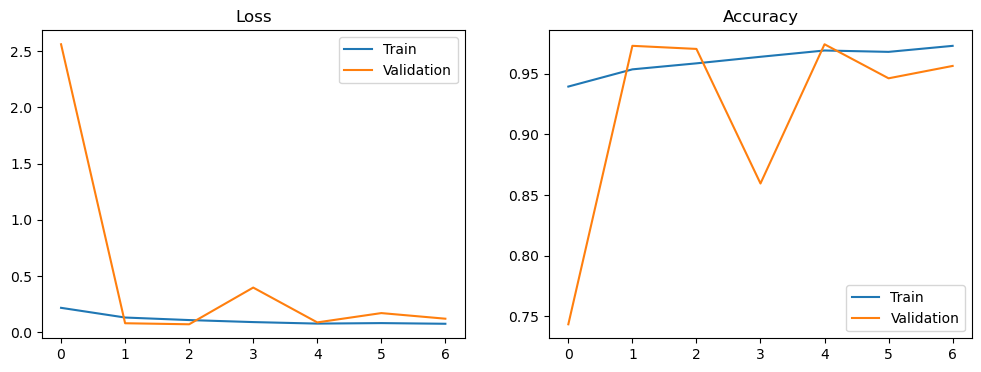

In [16]:
# TODO 5c: Plot training vs validation loss, and training vs validation accuracy,
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Accuracy")
plt.legend()

## Task 6 — Evaluate Properly

**Concept — why accuracy alone is misleading here:** imagine a trivial model
that always predicts PNEUMONIA. On an imbalanced test set that's majority
PNEUMONIA, that useless model still scores well above 50% accuracy despite
never correctly identifying a single NORMAL case. Per-class precision,
recall, and F1 expose that failure mode; overall accuracy hides it.


In [17]:
# TODO 6a: Build a test dataset the same way as val_ds (NO augmentation -- this is your
test_paths = []
test_labels = []

for cls, label in [("NORMAL", 0), ("PNEUMONIA", 1)]:
    folder = os.path.join(DATA_ROOT, "test", cls)

    for file in os.listdir(folder):
        test_paths.append(os.path.join(folder, file))
        test_labels.append(label)

test_ds = build_dataset(test_paths, test_labels)

print("Test images:", len(test_paths))

Test images: 624


In [18]:
# TODO 6b: Get predictions on the test set. model.predict(test_ds) returns probabilities;
y_true = np.array(test_labels)

y_prob = model.predict(test_ds).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(
    y_true,
    y_pred,
    target_names=["NORMAL", "PNEUMONIA"]
))

39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step
              precision    recall  f1-score   support

      NORMAL       1.00      0.20      0.33       234
   PNEUMONIA       0.67      1.00      0.81       390

    accuracy                           0.70       624
   macro avg       0.84      0.60      0.57       624
weighted avg       0.80      0.70      0.63       624



NORMAL recall: 0.197
False negatives: 0
False positives: 188


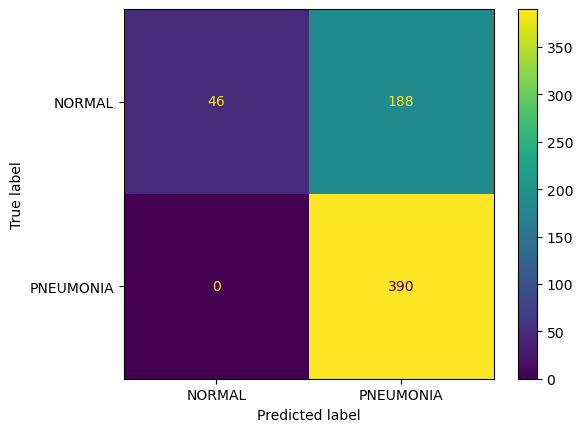

In [19]:
# TODO 6c: Compute and plot the confusion matrix (ConfusionMatrixDisplay).
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NORMAL", "PNEUMONIA"]
)

disp.plot()

normal_recall = cm[0, 0] / cm[0].sum()

print(f"NORMAL recall: {normal_recall:.3f}")
print(f"False negatives: {cm[1, 0]}")
print(f"False positives: {cm[0, 1]}")

**Your answer here (replace this text):** which error type is worse in
this context, false negative or false positive, and why?

For a medical pneumonia screening model, false negatives are generally worse because a false negative means a patient who actually has pneumonia was classified as NORMAL, potentially delaying diagnosis and treatment.

## Bonus (optional, harder)

**Concept — ablation:** change exactly one variable (class weighting) while
holding everything else constant, so any difference in outcome can be
attributed specifically to that variable.


In [20]:
# TODO Bonus 1: Retrain an identical model architecture WITHOUT class_weight, and compare
model_no_weights = models.clone_model(model)

model_no_weights.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_no_weights = model_no_weights.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30


C:\Users\Abity\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


278/278 ━━━━━━━━━━━━━━━━━━━━ 57s 180ms/step - accuracy: 0.9323 - loss: 0.3033 - val_accuracy: 0.7433 - val_loss: 2.9653
Epoch 2/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 51s 177ms/step - accuracy: 0.9553 - loss: 0.1347 - val_accuracy: 0.7612 - val_loss: 1.2587
Epoch 3/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 51s 178ms/step - accuracy: 0.9628 - loss: 0.1010 - val_accuracy: 0.9783 - val_loss: 0.0676
Epoch 4/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 82s 179ms/step - accuracy: 0.9691 - loss: 0.0743 - val_accuracy: 0.9502 - val_loss: 0.1308
Epoch 5/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 51s 177ms/step - accuracy: 0.9707 - loss: 0.0856 - val_accuracy: 0.9387 - val_loss: 0.1799
Epoch 6/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 44s 151ms/step - accuracy: 0.9725 - loss: 0.0711 - val_accuracy: 0.9706 - val_loss: 0.0793
Epoch 7/30
278/278 ━━━━━━━━━━━━━━━━━━━━ 45s 155ms/step - accuracy: 0.9761 - loss: 0.0624 - val_accuracy: 0.9234 - val_loss: 0.1661


In [21]:
y_prob_no_weights = model_no_weights.predict(test_ds).ravel()
y_pred_no_weights = (y_prob_no_weights >= 0.5).astype(int)

print(classification_report(
    y_true,
    y_pred_no_weights,
    target_names=["NORMAL", "PNEUMONIA"]
))

39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step
              precision    recall  f1-score   support

      NORMAL       0.97      0.29      0.44       234
   PNEUMONIA       0.70      0.99      0.82       390

    accuracy                           0.73       624
   macro avg       0.84      0.64      0.63       624
weighted avg       0.80      0.73      0.68       624



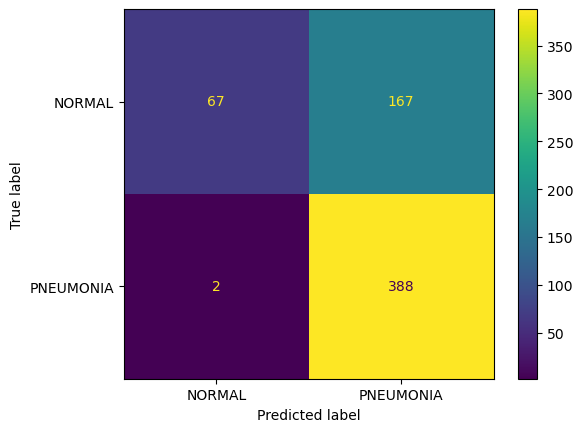

In [22]:
cm_no_weights = confusion_matrix(y_true, y_pred_no_weights)

ConfusionMatrixDisplay(
    confusion_matrix=cm_no_weights,
    display_labels=["NORMAL", "PNEUMONIA"]
).plot()

In [ ]:
# TODO Bonus 2 (harder): Swap in a pretrained MobileNetV2 base (frozen weights) with your
# own small classification head on top, and compare its performance and training time against
# your from-scratch CNN.
# Hint: tf.keras.applications.MobileNetV2(input_shape=..., include_top=False, weights="imagenet")
#       then set base_model.trainable = False before adding your own head.
# Note: MobileNetV2 expects 3-channel (RGB) input, and its own preprocessing normalization --
# check tf.keras.applications.mobilenet_v2.preprocess_input.


## Writeup

Fill in with your own results once you've run this end-to-end on the real dataset:

1. Your final test-set precision/recall/F1 **per class** (not just overall accuracy):
2. Whether class weighting changed your confusion matrix meaningfully — with actual before/after numbers:
3. One thing that surprised you about the preprocessing step:


1. Final test-set results:
NORMAL: Precision = 1.00, Recall = .2, F1 = .3
PNEUMONIA: Precision = .6, Recall = 1.0, F1 = .81
2. Effect of class weighting:
Class weighting did not meaningfully improve the confusion matrix. With class weighting, NORMAL recall was 0.20 and there were more missed NORMAL cases. Without weighting, NORMAL recall improved to 0.29, while PNEUMONIA recall remained almost perfect (1.00 vs 0.99). Accuracy also increased from 0.70 to 0.73 without weighting. In this experiment, class weighting did not help the model.
3. Preprocessing surprise:
I was surprised that the X-ray images had different sizes and some had different color modes, even though they were all X-rays. Resizing and converting them to grayscale made the inputs consistent for the CNN.